# The Soergel ring $R = \mathbb{Q}[\alpha_1,\alpha_2,\alpha_3]$

The algebra layer of `DiagrammaticHecke.jl`: the coefficient ring for diagram
labels, the type-A₃ reflection action, Demazure operators, and the
division-free linear algebra used in the circular-leaf sweeps.

Built on `AbstractAlgebra.jl` (pure Julia, no binary dependencies); the
package only adds the Soergel-specific layer on top.

In [1]:
using DiagrammaticHecke

## 1. The ring and its grading

`alpha(i)` is the simple root $\alpha_i$; every $\alpha_i$ has Soergel degree
**2**. `soergel_str` prints in the compact notation used inside diagram
renderings.

In [2]:
α1, α2, α3 = alpha(1), alpha(2), alpha(3)
p = 2 * α1^2 * α3 - α2
@show p degree(p) soergel_str(p)
poly_terms(p)   # sparse term dictionary, inverse of poly_from_terms

p = 

2*α₁^2*α₃ - α₂
degree(p) = 

6


soergel_str(p) = 

"2·α₁^2α₃ - α₂"


Dict{Tuple{Int64, Int64, Int64}, Rational{BigInt}} with 2 entries:
  (2, 0, 1) => 2
  (0, 1, 0) => -1

## 2. The A₃ reflection action

`act(s, f)` applies the simple reflection $s_s$ via the A₃ Cartan matrix:
$s_i(\alpha_i) = -\alpha_i$, $s_i(\alpha_j) = \alpha_j + \alpha_i$ for
$|i-j|=1$, and $s_i(\alpha_j) = \alpha_j$ otherwise. It is an involution.

In [3]:
@show act(1, α1) act(1, α2) act(1, α3)
f = α1^2 + α2 * α3 - 3 // 2 * α1
act(1, act(1, f)) == f

act(1, α1) = -α₁
act(1, α2) = α₁ + α₂
act(1, α3) = α₃


true

## 3. Demazure operators

$\Delta_s(f) = (f - s\cdot f)/\alpha_s$ (`demazure`, alias `δ`). Standard
identities: $\Delta_s(\alpha_s) = 2$, $\Delta_s \circ \Delta_s = 0$, and the
image of $\Delta_s$ is $s$-invariant.

In [4]:
@show demazure(1, α1) demazure(1, α2) demazure(2, α1 * α2 + α2 * α3)
@show iszero(δ(2, δ(2, f)))
act(2, δ(2, f)) == δ(2, f)

demazure(1, α1) = 2


demazure(1, α2) = -1
demazure(2, α1 * α2 + α2 * α3) = 2*α₁ + 2*α₂ + 2*α₃
iszero(δ(2, δ(2, f))) = true


true

## 4. Division-free linear algebra over $R$

The one question the circular-leaf study asks about a coefficient matrix over
$R$: is it invertible over the fraction field $\mathrm{Frac}(R)$? Since $R$ is
an integral domain this is just $\det \neq 0$ **in $R$**. The matrices that
occur are extremely sparse, so two shortcuts run before any elimination:

- `is_permutation_triangular` — triangular up to row/column permutation
  (exact peeling, no determinant at all);
- `soergel_det_peeled` — Laplace-peels single-entry rows/columns and hands
  only the dense core to `soergel_det`.

In [5]:
M = [α1 one(R) one(R); zero(R) α2 one(R); zero(R) zero(R) α3]
@show soergel_det(M)
@show is_permutation_triangular(M[[3,1,2], [2,3,1]])   # permuted triangular
@show is_invertible_over_frac_ring(M)
soergel_det_peeled([α1 one(R); one(R) α2])   # (det, dense-core size, computed)

soergel_det(M) = α₁*α₂*α₃


is_permutation_triangular(M[[3, 1, 2], [2, 3, 1]]) = true


is_invertible_over_frac_ring(M) = true


(det = α₁*α₂ - 1, core = 2, computed = true)

## 5. The Bott–Samelson pairing

`bs_pairing(x, y)` is the graded dimension of $\operatorname{Hom}(BS(x), BS(y))$,
returned as a degree → coefficient dictionary. It is computed in the Hecke
algebra $H$ rather than tabulated.

Two ingredients. First, $H$ is free over $\mathbb{Z}[v, v^{-1}]$ on the standard
basis $\{\delta_w\}$, and $b_s = \delta_s + v\,\delta_e$; for a word
$x = i_1 i_2 \dots i_k$ write $bs(x) = b_{i_1} b_{i_2} \cdots b_{i_k}$. Second,
the Soergel pairing is $\langle h, h' \rangle = \varepsilon\bigl(h \cdot \omega(h')\bigr)$,
where $\varepsilon$ reads off the coefficient of $\delta_e$ and $\omega$ is the
antiautomorphism fixing every $\delta_s$.

Each $b_s$ is $\omega$-invariant, so $\omega$ applied to $bs(y)$ just turns the
product around. For $y = j_1 j_2 \dots j_l$ that gives

$$\langle bs(x), bs(y) \rangle \;=\; \varepsilon\bigl(\, b_{i_1} \cdots b_{i_k} \cdot b_{j_l} \cdots b_{j_1} \,\bigr) .$$

In words: multiply the generators of $x$ left to right, continue with those of
$y$ in reverse order, and read off one coefficient. One pass, no general Hecke
multiplication.

Degrees are exponents of $v$ and **may be negative** — `bs_pairing` of `121321`
with itself has a term in degree $-2$, a leaf with more trivalents than dots.

`pairing_table()` runs this over all 576 pairs of short-lex reduced words;
`expected_count` evaluates at $v = 1$, or in one degree. The double-leaves
construction is validated against these numbers.

In [6]:
@show bs_pairing([1,2,1], [1,2,1])        # 0:2 2:5 4:4 6:1
@show expected_count([1,2,1], [1,2,1])    # value at v = 1
@show expected_count([1,2,1], [1,2,1]; degree = 4)
length(pairing_table())                   # 24 x 24 short-lex pairs

bs_pairing([1, 2, 1], [1, 2, 1]) = Dict(0 => 2, 4 => 4, 6 => 1, 2 => 5)
expected_count([1, 2, 1], [1, 2, 1]) = 12
expected_count([1, 2, 1], [1, 2, 1]; degree = 4) = 4


576

## 6. Where these polynomials sit

In a diagram every **region** carries one element of $R$. That is the whole
interface between this layer and the rest of the package: `CircularDecorated`
stores one polynomial per region, and the rules move them around with the
Demazure operators of §3.

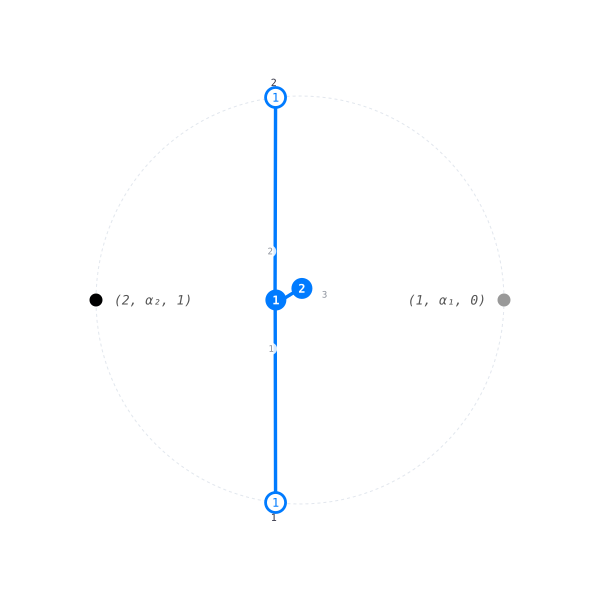

In [7]:
debug_circular(true)                      # region numbers in the picture
fm = circular_morphism(morphism_graph(unit_graph(), 0, 0))
display(CircularDecoratedMorphism(fm, [alpha(1), alpha(2)]))